In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import pandas as pd
from tqdm import tqdm 

In [2]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)
    
def load_individual_trajectory(filename):
    """Load a single trajectory from pickle file - no changes needed"""
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    
    print(f"Loaded trajectory: {data['metadata']['trajectory_name']}")
    print(f"  Frame count: {data['metadata']['frame_count']}")
    print(f"  Parameters: {data['metadata']['parameters']}")
    
    return data

def load_convergence_data(filename):
    """Load convergence data from pickle file"""
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    
    print("Loaded data summary:")
   # print(f"  Timestamp: {data['metadata']['timestamp']}")
    print(f"  Number of walkers: {data['metadata']['n_walkers']}")
    print(f"  Total frames per walker: {data['metadata']['walker_frame_counts']}")
    print(f"  Parameters: {data['metadata']['parameters']}")
    
    return data

### 8omg

In [3]:
import pandas as pd

df_stationary_p = pd.read_csv("autocooreldata/autocoorel_data_omg8rep/trans_population_at_lagtime_8conforms.csv")
print(df_stationary_p)

# Set 'conform_state' as index instead of pivot
pivot_mean = df_stationary_p.set_index('conform_state')['mean']
pivot_std = df_stationary_p.set_index('conform_state')['std']

# Convert to NumPy arrays
trans_refer_array = pivot_mean.to_numpy()
trans_refer_err_array = pivot_std.to_numpy()

print("Array shape:", trans_refer_array.shape)
print(trans_refer_array)


   conform_state  lagtime_index  lagtime_ns      mean       std
0              0              6         2.2  0.081357  0.010957
1              1              6         2.2  0.093396  0.010657
2              2              6         2.2  0.076178  0.008522
3              3              6         2.2  0.086172  0.011123
4              4              6         2.2  0.147792  0.011585
5              5              6         2.2  0.191021  0.013323
6              6              6         2.2  0.146395  0.017803
7              7              6         2.2  0.177689  0.011617
Array shape: (8,)
[0.08135737 0.0933961  0.07617768 0.08617183 0.14779227 0.19102109
 0.14639486 0.1776888 ]


In [4]:
# Later, load and plot
omg8rep_meta_data = load_convergence_data(f"convergence_data/8omg_metadynamics_convergence.pkl")

# Extract data
averaged_conv = omg8rep_meta_data['averaged_convergence']
individual_conv = omg8rep_meta_data.get('individual_walker_convergence', {})
state_labels = omg8rep_meta_data['metadata']['state_labels']
dt = omg8rep_meta_data['metadata']['parameters']['dt']


Loaded data summary:
  Number of walkers: 8
  Total frames per walker: {1: 207776, 2: 207776, 3: 207776, 4: 207776, 5: 207776, 6: 207776, 7: 207776, 8: 207776}
  Parameters: {'window_size': 1000, 'dt': 0.002, 'temperature': 2.5, 'normalization': 'minimum'}


In [5]:
for key, value in averaged_conv.items():
    print(f"{key}: type={type(value)}, shape/len={getattr(value, 'shape', len(value)) if hasattr(value, '__len__') else 'N/A'}")


frames: type=<class 'list'>, shape/len=207
populations: type=<class 'dict'>, shape/len=8
free_energies: type=<class 'dict'>, shape/len=8
pop_std: type=<class 'dict'>, shape/len=8
fe_std: type=<class 'dict'>, shape/len=8


In [6]:
pops_dict = averaged_conv['populations']
pop_std_dict = averaged_conv['pop_std']

sorted_states = sorted(pops_dict.keys())  # ensure [1..8]
pops_over_time = np.array([pops_dict[state] for state in sorted_states])          # shape (8, 205)
pops_std_over_time = np.array([pop_std_dict[state] for state in sorted_states])   # shape (8, 205)

print("pops_over_time:", pops_over_time.shape)
print("pops_std_over_time:", pops_std_over_time.shape)


pops_over_time: (8, 207)
pops_std_over_time: (8, 207)


In [7]:
res_trans_pops = []
res_trans_stds = []
trans_index = {0: [3,4,5,7], 1: [2,4,6,7], 2: [1,5,6,7]}

for idx, (residue, states) in enumerate(trans_index.items()):
    # states are 1-based (1..8), convert to 0-based indices for numpy
    state_indices = [s for s in states]
    print(state_indices)

    # select relevant populations and stds
    pops_subset = pops_over_time[state_indices, :]        # shape (#states, n_frames)
    stds_subset = pops_std_over_time[state_indices, :]    # shape (#states, n_frames)

    # sum populations
    res_pop = np.sum(pops_subset, axis=0)

    # combine stds in quadrature (assuming independent)
    res_std = np.sqrt(np.sum(stds_subset**2, axis=0))

    res_trans_pops.append(res_pop)
    res_trans_stds.append(res_std)

    print(f"Residue {residue}: summed from states {states}, shape={res_pop.shape}")

res_trans_pops = np.array(res_trans_pops)   # shape (3, 205)
res_trans_stds = np.array(res_trans_stds)   # shape (3, 205)

print("res_trans_pops shape:", res_trans_pops.shape)
print("res_trans_stds shape:", res_trans_stds.shape)

[3, 4, 5, 7]
Residue 0: summed from states [3, 4, 5, 7], shape=(207,)
[2, 4, 6, 7]
Residue 1: summed from states [2, 4, 6, 7], shape=(207,)
[1, 5, 6, 7]
Residue 2: summed from states [1, 5, 6, 7], shape=(207,)
res_trans_pops shape: (3, 207)
res_trans_stds shape: (3, 207)


In [10]:
import pandas as pd

df_stationary_p = pd.read_csv("autocooreldata/autocoorel_data_omg8rep/trans_population_at_lagtime_res_conforms.csv")
print(df_stationary_p)

# Set 'conform_state' as index instead of pivot
pivot_mean = df_stationary_p.set_index('lagtime_ns')['mean']
pivot_std = df_stationary_p.set_index('lagtime_ns')['std']

# Convert to NumPy arrays
trans_refer_array = pivot_mean.to_numpy()
trans_refer_err_array = pivot_std.to_numpy()

print("Array shape:", trans_refer_array.shape)
print(trans_refer_array)


   residue  lagtime_index  lagtime_ns      mean       std
0        0              6         2.2  0.663147  0.018988
1        1              6         2.2  0.486173  0.022010
2        2              6         2.2  0.548402  0.018906
Array shape: (3,)
[0.66314739 0.48617329 0.54840164]


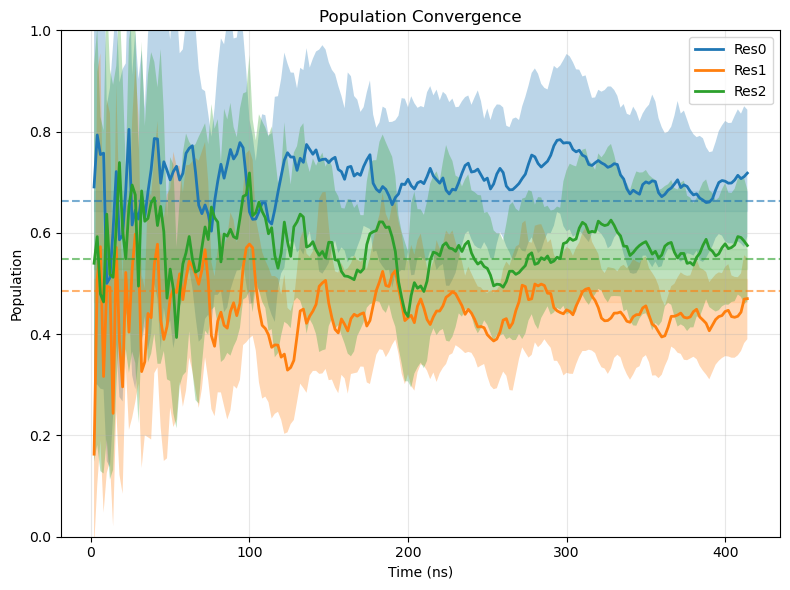

In [11]:
# Convert to time
time_ps = [frame * dt for frame in averaged_conv['frames']]

plt.figure(figsize=(8, 6))

for i in range(3):

    pops = res_trans_pops[i]
    stds = res_trans_stds[i]
    plt.plot(time_ps, pops, label=f'Res{i}',
            linewidth=2)

    plt.fill_between(time_ps,
                    [p - e for p, e in zip(pops, stds)],
                    [p + e for p, e in zip(pops, stds)],
                    alpha=0.3)

# Reference horizontal line
    ref_y = trans_refer_array[i]
    ref_yerr = trans_refer_err_array[i]
    plt.axhline(y=ref_y, linestyle='--', color=f'C{i}', alpha=0.6)
    plt.fill_between(time_ps, ref_y - ref_yerr, ref_y + ref_yerr, color=f'C{i}', alpha=0.1)


plt.xlabel('Time (ns)')
plt.ylabel('Population')
plt.title('Population Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


In [12]:
import os

print(res_trans_pops.shape)
print(res_trans_stds.shape)
os.makedirs('population_data', exist_ok=True)
population_result = [res_trans_pops, res_trans_stds]
data_instance = Data(population_result)
data_instance.save("population_data/8omg_metadynamics_population_res.pkl")

(3, 207)
(3, 207)


In [13]:
import pandas as pd

df_stationary_p = pd.read_csv("autocooreldata/autocoorel_data_oppc8rep/trans_population_at_lagtime_res_conforms.csv")
print(df_stationary_p)

# Set 'conform_state' as index instead of pivot
pivot_mean = df_stationary_p.set_index('lagtime_ns')['mean']
pivot_std = df_stationary_p.set_index('lagtime_ns')['std']

# Convert to NumPy arrays
trans_refer_array = pivot_mean.to_numpy()
trans_refer_err_array = pivot_std.to_numpy()

print("Array shape:", trans_refer_array.shape)
print(trans_refer_array)


   residue  lagtime_index  lagtime_ns      mean       std
0        0              6         2.2  0.689620  0.024168
1        1              6         2.2  0.482488  0.044022
2        2              6         2.2  0.564774  0.023324
Array shape: (3,)
[0.6896197  0.48248774 0.56477353]


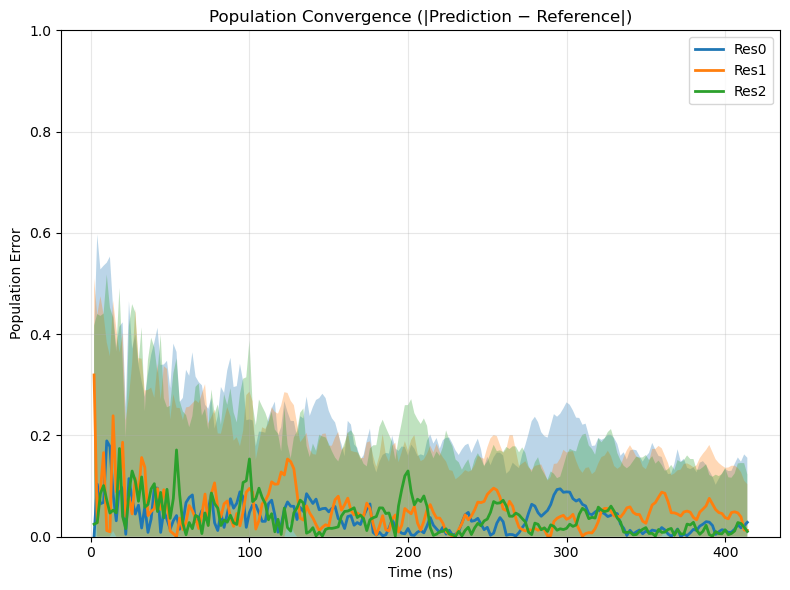

In [14]:
# Convert to time
time_ps = [frame * dt for frame in averaged_conv['frames']]

plt.figure(figsize=(8, 6))

error_all = []
error_err_all = []

for i in range(3):
    pops    = np.asarray(res_trans_pops[i])           # shape: (T,)
    stds    = np.asarray(res_trans_stds[i])           # per-time pop std
    ref_pop = np.asarray(trans_refer_array[i])        # reference pop
    ref_err = np.asarray(trans_refer_err_array[i])    # per-time ref std (or scalar OK)

    # Absolute error vs reference
    error = np.abs(pops - ref_pop)

    # Propagate uncertainty per time point
    error_err = np.sqrt(ref_err**2 + stds**2)

    # Save for later if needed
    error_all.append(error)
    error_err_all.append(error_err)

    # Plot mean error
    plt.plot(time_ps, error, label=f"Res{i}", linewidth=2)

    # Plot error band; keep within [0, 1]
    lower = np.clip(error - error_err, 0.0, None)
    upper = np.clip(error + error_err, 0.0, 1.0)
    plt.fill_between(time_ps, lower, upper, alpha=0.3)

plt.xlabel('Time (ns)')
plt.ylabel('Population Error')
plt.title('Population Convergence (|Prediction − Reference|)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [15]:
import os
error_all = np.array(error_all)
error_err_all = np.array(error_err_all)

print(error_all.shape)
print(error_err_all.shape)
os.makedirs('population_data', exist_ok=True)
error_results = [error_all, error_err_all]
data_instance = Data(error_results)
data_instance.save("population_data/8omg_metadynamics_error_res.pkl")

(3, 207)
(3, 207)


### 8oppc

In [16]:
import pandas as pd

df_stationary_p = pd.read_csv("autocooreldata/autocoorel_data_oppc8rep/trans_population_at_lagtime_8conforms.csv")
print(df_stationary_p)

# Set 'conform_state' as index instead of pivot
pivot_mean = df_stationary_p.set_index('conform_state')['mean']
pivot_std = df_stationary_p.set_index('conform_state')['std']

# Convert to NumPy arrays
trans_refer_array = pivot_mean.to_numpy()
trans_refer_err_array = pivot_std.to_numpy()

print("Array shape:", trans_refer_array.shape)
print(trans_refer_array)


   conform_state  lagtime_index  lagtime_ns      mean       std
0              0              6         2.2  0.070003  0.009896
1              1              6         2.2  0.083030  0.012337
2              2              6         2.2  0.074649  0.020366
3              3              6         2.2  0.082610  0.017814
4              4              6         2.2  0.146876  0.018396
5              5              6         2.2  0.217434  0.040807
6              6              6         2.2  0.142872  0.010911
7              7              6         2.2  0.182527  0.025288
Array shape: (8,)
[0.07000262 0.08302984 0.07464873 0.08260975 0.14687599 0.21743441
 0.14287185 0.18252682]


In [17]:
# Later, load and plot
omg8rep_meta_data = load_convergence_data(f"convergence_data/8oppc_metadynamics_convergence.pkl")

# Extract data
averaged_conv = omg8rep_meta_data['averaged_convergence']
individual_conv = omg8rep_meta_data.get('individual_walker_convergence', {})
state_labels = omg8rep_meta_data['metadata']['state_labels']
dt = omg8rep_meta_data['metadata']['parameters']['dt']


Loaded data summary:
  Number of walkers: 8
  Total frames per walker: {1: 205058, 2: 205058, 3: 205058, 4: 205058, 5: 205058, 6: 205058, 7: 205058, 8: 205058}
  Parameters: {'window_size': 1000, 'dt': 0.002, 'temperature': 2.5, 'normalization': 'minimum'}


In [18]:
for key, value in averaged_conv.items():
    print(f"{key}: type={type(value)}, shape/len={getattr(value, 'shape', len(value)) if hasattr(value, '__len__') else 'N/A'}")


frames: type=<class 'list'>, shape/len=205
populations: type=<class 'dict'>, shape/len=8
free_energies: type=<class 'dict'>, shape/len=8
pop_std: type=<class 'dict'>, shape/len=8
fe_std: type=<class 'dict'>, shape/len=8


In [19]:
pops_dict = averaged_conv['populations']
pop_std_dict = averaged_conv['pop_std']

sorted_states = sorted(pops_dict.keys())  # ensure [1..8]
pops_over_time = np.array([pops_dict[state] for state in sorted_states])          # shape (8, 205)
pops_std_over_time = np.array([pop_std_dict[state] for state in sorted_states])   # shape (8, 205)

print("pops_over_time:", pops_over_time.shape)
print("pops_std_over_time:", pops_std_over_time.shape)


pops_over_time: (8, 205)
pops_std_over_time: (8, 205)


In [20]:
res_trans_pops = []
res_trans_stds = []
trans_index = {0: [3,4,5,7], 1: [2,4,6,7], 2: [1,5,6,7]}

for idx, (residue, states) in enumerate(trans_index.items()):
    # states are 1-based (1..8), convert to 0-based indices for numpy
    state_indices = [s for s in states]
    print(state_indices)

    # select relevant populations and stds
    pops_subset = pops_over_time[state_indices, :]        # shape (#states, n_frames)
    stds_subset = pops_std_over_time[state_indices, :]    # shape (#states, n_frames)

    # sum populations
    res_pop = np.sum(pops_subset, axis=0)

    # combine stds in quadrature (assuming independent)
    res_std = np.sqrt(np.sum(stds_subset**2, axis=0))

    res_trans_pops.append(res_pop)
    res_trans_stds.append(res_std)

    print(f"Residue {residue}: summed from states {states}, shape={res_pop.shape}")

res_trans_pops = np.array(res_trans_pops)   # shape (3, 205)
res_trans_stds = np.array(res_trans_stds)   # shape (3, 205)

print("res_trans_pops shape:", res_trans_pops.shape)
print("res_trans_stds shape:", res_trans_stds.shape)

[3, 4, 5, 7]
Residue 0: summed from states [3, 4, 5, 7], shape=(205,)
[2, 4, 6, 7]
Residue 1: summed from states [2, 4, 6, 7], shape=(205,)
[1, 5, 6, 7]
Residue 2: summed from states [1, 5, 6, 7], shape=(205,)
res_trans_pops shape: (3, 205)
res_trans_stds shape: (3, 205)


In [21]:
import pandas as pd

df_stationary_p = pd.read_csv("autocooreldata/autocoorel_data_oppc8rep/trans_population_at_lagtime_res_conforms.csv")
print(df_stationary_p)

# Set 'conform_state' as index instead of pivot
pivot_mean = df_stationary_p.set_index('lagtime_ns')['mean']
pivot_std = df_stationary_p.set_index('lagtime_ns')['std']

# Convert to NumPy arrays
trans_refer_array = pivot_mean.to_numpy()
trans_refer_err_array = pivot_std.to_numpy()

print("Array shape:", trans_refer_array.shape)
print(trans_refer_array)


   residue  lagtime_index  lagtime_ns      mean       std
0        0              6         2.2  0.689620  0.024168
1        1              6         2.2  0.482488  0.044022
2        2              6         2.2  0.564774  0.023324
Array shape: (3,)
[0.6896197  0.48248774 0.56477353]


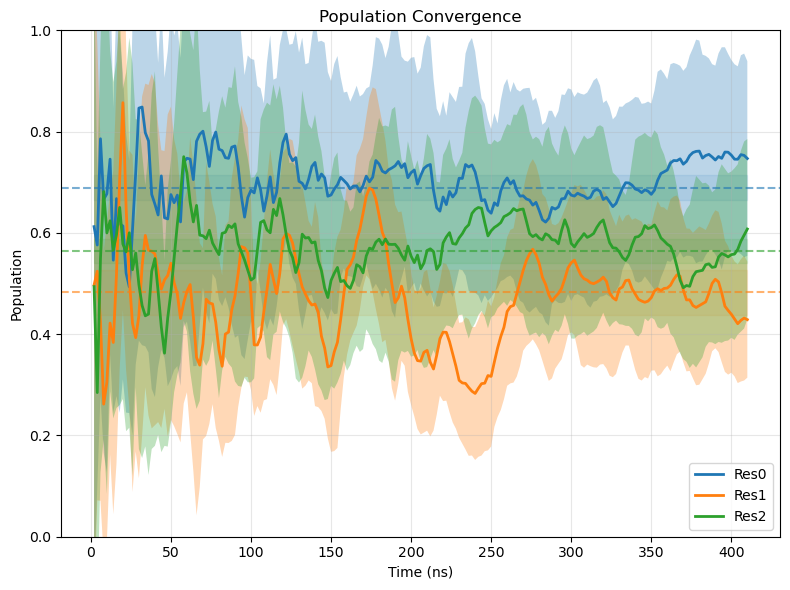

In [22]:
# Convert to time
time_ps = [frame * dt for frame in averaged_conv['frames']]

plt.figure(figsize=(8, 6))

for i in range(3):

    pops = res_trans_pops[i]
    stds = res_trans_stds[i]
    plt.plot(time_ps, pops, label=f'Res{i}',
            linewidth=2)

    plt.fill_between(time_ps,
                    [p - e for p, e in zip(pops, stds)],
                    [p + e for p, e in zip(pops, stds)],
                    alpha=0.3)

# Reference horizontal line
    ref_y = trans_refer_array[i]
    ref_yerr = trans_refer_err_array[i]
    plt.axhline(y=ref_y, linestyle='--', color=f'C{i}', alpha=0.6)
    plt.fill_between(time_ps, ref_y - ref_yerr, ref_y + ref_yerr, color=f'C{i}', alpha=0.1)


plt.xlabel('Time (ns)')
plt.ylabel('Population')
plt.title('Population Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


In [23]:
import os

print(res_trans_pops.shape)
print(res_trans_stds.shape)
os.makedirs('population_data', exist_ok=True)
population_result = [res_trans_pops, res_trans_stds]
data_instance = Data(population_result)
data_instance.save("population_data/8oppc_metadynamics_population_res.pkl")

(3, 205)
(3, 205)


In [24]:
import pandas as pd

df_stationary_p = pd.read_csv("autocooreldata/autocoorel_data_oppc8rep/trans_population_at_lagtime_res_conforms.csv")
print(df_stationary_p)

# Set 'conform_state' as index instead of pivot
pivot_mean = df_stationary_p.set_index('lagtime_ns')['mean']
pivot_std = df_stationary_p.set_index('lagtime_ns')['std']

# Convert to NumPy arrays
trans_refer_array = pivot_mean.to_numpy()
trans_refer_err_array = pivot_std.to_numpy()

print("Array shape:", trans_refer_array.shape)
print(trans_refer_array)


   residue  lagtime_index  lagtime_ns      mean       std
0        0              6         2.2  0.689620  0.024168
1        1              6         2.2  0.482488  0.044022
2        2              6         2.2  0.564774  0.023324
Array shape: (3,)
[0.6896197  0.48248774 0.56477353]


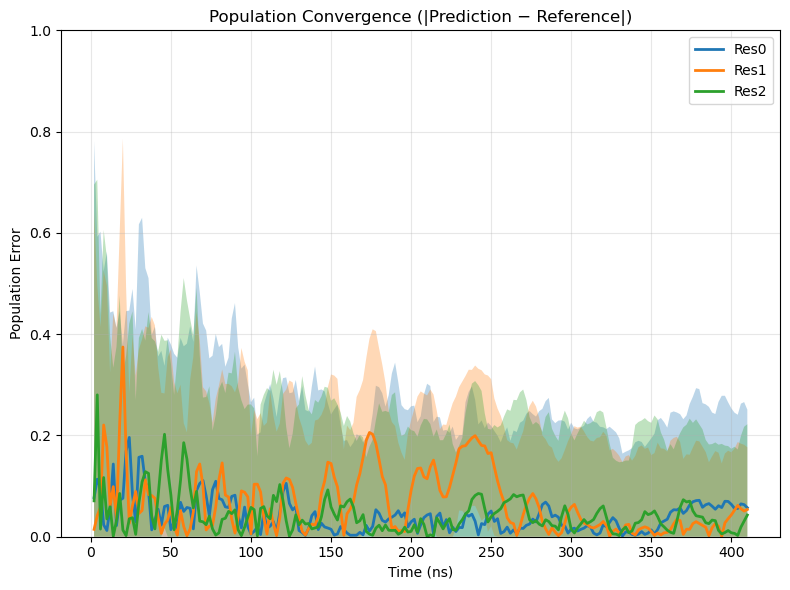

In [25]:
# Convert to time
time_ps = [frame * dt for frame in averaged_conv['frames']]

plt.figure(figsize=(8, 6))

error_all = []
error_err_all = []

for i in range(3):
    pops    = np.asarray(res_trans_pops[i])           # shape: (T,)
    stds    = np.asarray(res_trans_stds[i])           # per-time pop std
    ref_pop = np.asarray(trans_refer_array[i])        # reference pop
    ref_err = np.asarray(trans_refer_err_array[i])    # per-time ref std (or scalar OK)

    # Absolute error vs reference
    error = np.abs(pops - ref_pop)

    # Propagate uncertainty per time point
    error_err = np.sqrt(ref_err**2 + stds**2)

    # Save for later if needed
    error_all.append(error)
    error_err_all.append(error_err)

    # Plot mean error
    plt.plot(time_ps, error, label=f"Res{i}", linewidth=2)

    # Plot error band; keep within [0, 1]
    lower = np.clip(error - error_err, 0.0, None)
    upper = np.clip(error + error_err, 0.0, 1.0)
    plt.fill_between(time_ps, lower, upper, alpha=0.3)

plt.xlabel('Time (ns)')
plt.ylabel('Population Error')
plt.title('Population Convergence (|Prediction − Reference|)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [26]:
import os
error_all = np.array(error_all)
error_err_all = np.array(error_err_all)

print(error_all.shape)
print(error_err_all.shape)
os.makedirs('population_data', exist_ok=True)
error_results = [error_all, error_err_all]
data_instance = Data(error_results)
data_instance.save("population_data/8oppc_metadynamics_error_res.pkl")

(3, 205)
(3, 205)
